# TD5: Mesh Graph Networks for Flow Field Prediction

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import pyvista as pv
import matplotlib.pyplot as plt
from pathlib import Path
import json
from scipy.spatial import cKDTree
from torch_geometric.data import Data, Batch
from torch_geometric.nn import GCNConv, MessagePassing
from torch_geometric.utils import to_undirected
import warnings
warnings.filterwarnings('ignore')

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device} ({torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu"})')
print(f'PyTorch {torch.__version__}')

Device: cuda (Tesla T4)
PyTorch 2.8.0+cu128


## Q1: Data Loading and Preprocessing

In [2]:
DATA_DIR = Path('dataset/samples_centered')
sim_dirs = sorted([d for d in DATA_DIR.iterdir() if d.is_dir() and 'simulation' in d.name])
print(f'Found {len(sim_dirs)} simulations')

# Load one mesh to inspect
mesh0 = pv.read(str(sim_dirs[0] / f'{sim_dirs[0].name}.vtu'))
print(f'Points: {mesh0.points.shape}, Cells: {mesh0.n_cells}')
print(f'Point data: {list(mesh0.point_data.keys())}')
print(f'Domain: x=[{mesh0.points[:,0].min():.2f}, {mesh0.points[:,0].max():.2f}], y=[{mesh0.points[:,1].min():.2f}, {mesh0.points[:,1].max():.2f}]')

# Check metadata
with open(sim_dirs[0] / 'metadata.json') as f:
    meta0 = json.load(f)
print(f'Metadata: {meta0}')

Found 38 simulations
Points: (6588, 3), Cells: 12763
Point data: ['mean_velocity', 'velocity_magnitude', 'mean_pressure', 'implicit_distance']
Domain: x=[0.00, 2.20], y=[0.00, 0.41]
Metadata: {'length': 2.2, 'height': 0.41, 'radius': 0.05, 'inlet_velocity': 0.05, 'viscosity': 0.001, 'density': 1.0, 'reynolds': 5.000000000000001, 'simulation_time': 8.0, 'dt': 0.000625, 'num_steps': 12800}


In [3]:
def classify_nodes(points_2d, length=2.2, height=0.41, tol=1e-4):
    """Classify nodes: 0=boundary (walls+obstacle), 1=interior, 2=inlet, 3=outlet."""
    x, y = points_2d[:, 0], points_2d[:, 1]
    node_type = np.ones(len(points_2d), dtype=np.int64)  # default interior

    # Walls: y=0 or y=height
    wall_mask = (np.abs(y) < tol) | (np.abs(y - height) < tol)
    node_type[wall_mask] = 0

    # Inlet: x=0
    inlet_mask = np.abs(x) < tol
    node_type[inlet_mask] = 2

    # Outlet: x=length
    outlet_mask = np.abs(x - length) < tol
    node_type[outlet_mask] = 3

    # Obstacle: nodes near center that are on boundary (use implicit_distance ~ 0)
    # We'll detect obstacle nodes as boundary nodes not on walls/inlet/outlet
    return node_type

def compute_sdf(points_2d, boundary_points_2d):
    """Signed distance function from each node to nearest boundary point."""
    tree = cKDTree(boundary_points_2d)
    dist, _ = tree.query(points_2d)
    return dist

def build_edge_index(mesh):
    """Extract edge index from triangle mesh connectivity."""
    cells = mesh.cells.reshape(-1, 4)  # [3, n1, n2, n3] for triangles
    edges = set()
    for cell in cells:
        n = cell[0]
        pts = cell[1:1+n]
        for i in range(n):
            for j in range(i+1, n):
                edges.add((pts[i], pts[j]))
                edges.add((pts[j], pts[i]))  # both directions
    edge_index = np.array(list(edges), dtype=np.int64).T
    return edge_index

# Test on first simulation
pts0 = mesh0.points[:, :2]
boundary0 = mesh0.extract_feature_edges(boundary_edges=True, non_manifold_edges=False, 
                                         feature_edges=False, manifold_edges=False)
bnd_pts0 = boundary0.points[:, :2]
node_types0 = classify_nodes(pts0)

# Mark obstacle nodes: boundary points not on walls/inlet/outlet  
# detect as points that are on the feature edges but classified as interior
bnd_tree = cKDTree(bnd_pts0)
dist_to_bnd, _ = bnd_tree.query(pts0)
obstacle_mask = (dist_to_bnd < 1e-4) & (node_types0 == 1)
node_types0[obstacle_mask] = 0

sdf0 = compute_sdf(pts0, bnd_pts0)
edge_index0 = build_edge_index(mesh0)

print(f'Node types: boundary={np.sum(node_types0==0)}, interior={np.sum(node_types0==1)}, inlet={np.sum(node_types0==2)}, outlet={np.sum(node_types0==3)}')
print(f'SDF range: [{sdf0.min():.4f}, {sdf0.max():.4f}]')
print(f'Edge index shape: {edge_index0.shape}')

Node types: boundary=355, interior=6175, inlet=29, outlet=29
SDF range: [0.0000, 0.2049]
Edge index shape: (2, 38702)


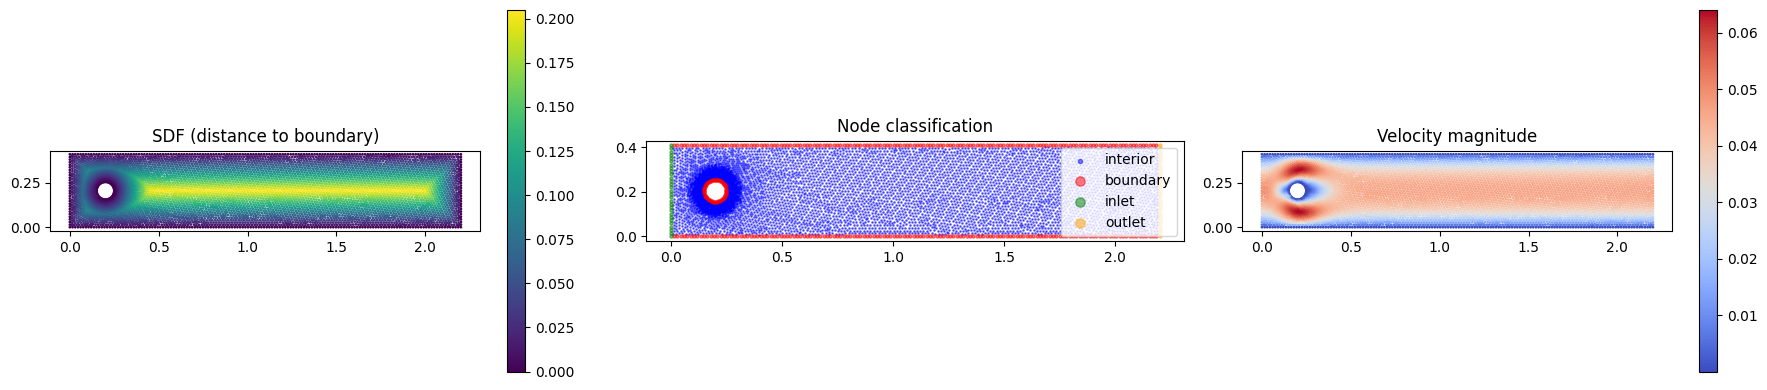

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# SDF
sc0 = axes[0].scatter(pts0[:,0], pts0[:,1], c=sdf0, s=1, cmap='viridis')
plt.colorbar(sc0, ax=axes[0]); axes[0].set_title('SDF (distance to boundary)')
axes[0].set_aspect('equal')

# Node types
colors = {0: 'red', 1: 'blue', 2: 'green', 3: 'orange'}
labels = {0: 'boundary', 1: 'interior', 2: 'inlet', 3: 'outlet'}
for t in [1, 0, 2, 3]:
    mask = node_types0 == t
    axes[1].scatter(pts0[mask,0], pts0[mask,1], c=colors[t], s=1 if t==1 else 5, label=labels[t], alpha=0.5)
axes[1].legend(markerscale=3); axes[1].set_title('Node classification')
axes[1].set_aspect('equal')

# Flow fields
vel = mesh0.point_data['mean_velocity']
sc2 = axes[2].scatter(pts0[:,0], pts0[:,1], c=np.sqrt(vel[:,0]**2 + vel[:,1]**2), s=1, cmap='coolwarm')
plt.colorbar(sc2, ax=axes[2]); axes[2].set_title('Velocity magnitude')
axes[2].set_aspect('equal')

plt.tight_layout(); plt.show()

SDF peaks in the channel center far from walls. Node classification correctly identifies walls (red), obstacle (red, center), inlet (green, left), and outlet (orange, right). Low Reynolds number (Re=5) gives smooth symmetric flow.

## Q2: Building PyG Data Objects and Model

In [5]:
def mesh_to_pyg(sim_dir, length=2.2, height=0.41):
    """Convert a VTU simulation to a PyG Data object."""
    sim_name = sim_dir.name
    mesh = pv.read(str(sim_dir / f'{sim_name}.vtu'))
    with open(sim_dir / 'metadata.json') as f:
        meta = json.load(f)
    
    pts = mesh.points[:, :2].astype(np.float32)
    n_nodes = len(pts)
    
    # Boundary extraction and SDF
    boundary = mesh.extract_feature_edges(boundary_edges=True, non_manifold_edges=False,
                                           feature_edges=False, manifold_edges=False)
    bnd_pts = boundary.points[:, :2]
    sdf = compute_sdf(pts, bnd_pts).astype(np.float32)
    
    # Node classification
    node_type = classify_nodes(pts, length, height)
    bnd_tree = cKDTree(bnd_pts)
    dist_to_bnd, _ = bnd_tree.query(pts)
    obstacle_mask = (dist_to_bnd < 1e-4) & (node_type == 1)
    node_type[obstacle_mask] = 0
    
    # One-hot encode node type (4 classes)
    node_type_onehot = np.eye(4, dtype=np.float32)[node_type]
    
    # Node features: [x, y, sdf, node_type_onehot(4), inlet_velocity]
    inlet_vel = np.full((n_nodes, 1), meta['inlet_velocity'], dtype=np.float32)
    node_features = np.concatenate([pts, sdf[:, None], node_type_onehot, inlet_vel], axis=1)
    
    # Edge index from mesh connectivity
    edge_index = build_edge_index(mesh)
    
    # Edge features: relative position and distance
    src, dst = edge_index[0], edge_index[1]
    rel_pos = pts[dst] - pts[src]  # (dx, dy)
    edge_dist = np.linalg.norm(rel_pos, axis=1, keepdims=True)
    edge_attr = np.concatenate([rel_pos, edge_dist], axis=1).astype(np.float32)
    
    # Targets: u, v, p
    vel = mesh.point_data['mean_velocity'].astype(np.float32)
    pressure = mesh.point_data['mean_pressure'].astype(np.float32)
    targets = np.column_stack([vel[:, 0], vel[:, 1], pressure])
    
    return Data(
        x=torch.tensor(node_features),
        edge_index=torch.tensor(edge_index, dtype=torch.long),
        edge_attr=torch.tensor(edge_attr),
        y=torch.tensor(targets),
        pos=torch.tensor(pts),
        node_type=torch.tensor(node_type, dtype=torch.long),
        inlet_velocity=torch.tensor([meta['inlet_velocity']], dtype=torch.float32),
    )

# Build all data objects
print('Loading all simulations...')
all_data = []
for i, sd in enumerate(sim_dirs):
    data = mesh_to_pyg(sd)
    all_data.append(data)
    if (i+1) % 10 == 0:
        print(f'  Loaded {i+1}/{len(sim_dirs)}')

print(f'\nTotal: {len(all_data)} graphs')
print(f'Example: {all_data[0]}')
print(f'Node features dim: {all_data[0].x.shape[1]}, Edge features dim: {all_data[0].edge_attr.shape[1]}')

Loading all simulations...


  Loaded 10/38


  Loaded 20/38


  Loaded 30/38



Total: 38 graphs
Example: Data(x=[6588, 8], edge_index=[2, 38702], edge_attr=[38702, 3], y=[6588, 3], pos=[6588, 2], node_type=[6588], inlet_velocity=[1])
Node features dim: 8, Edge features dim: 3


In [6]:
# Train/test split (30 train, 8 test)
np.random.seed(42)
indices = np.random.permutation(len(all_data))
n_train = 30
train_data = [all_data[i] for i in indices[:n_train]]
test_data = [all_data[i] for i in indices[n_train:]]
print(f'Train: {len(train_data)}, Test: {len(test_data)}')

# Compute normalization stats from training set
all_y_train = torch.cat([d.y for d in train_data], dim=0)
y_mean = all_y_train.mean(dim=0)
y_std = all_y_train.std(dim=0)
print(f'Target stats: mean={y_mean.numpy()}, std={y_std.numpy()}')

all_x_train = torch.cat([d.x for d in train_data], dim=0)
x_mean = all_x_train.mean(dim=0)
x_std = all_x_train.std(dim=0)
x_std[x_std < 1e-6] = 1.0  # avoid division by zero for constant features

# Normalize features and targets
for d in train_data + test_data:
    d.x = (d.x - x_mean) / x_std
    d.y_raw = d.y.clone()
    d.y = (d.y - y_mean) / y_std

print('Normalized features and targets')

Train: 30, Test: 8
Target stats: mean=[ 6.6341412e-01 -2.2235326e-04  5.0025906e-02], std=[0.5890959  0.16789624 0.3051291 ]
Normalized features and targets


In [7]:
class Encoder(nn.Module):
    def __init__(self, input_dim, latent_dim, hidden_dim):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, latent_dim),
        )
    def forward(self, x):
        return self.mlp(x)

class CustomMessagePassing(MessagePassing):
    def __init__(self, latent_dim, edge_dim):
        super().__init__(aggr='add')
        self.edge_mlp = nn.Sequential(
            nn.Linear(2 * latent_dim + edge_dim, latent_dim), nn.ReLU(),
            nn.Linear(latent_dim, latent_dim),
        )
        self.node_mlp = nn.Sequential(
            nn.Linear(2 * latent_dim, latent_dim), nn.ReLU(),
            nn.Linear(latent_dim, latent_dim),
        )
        self.norm = nn.LayerNorm(latent_dim)

    def forward(self, x, edge_index, edge_attr):
        msg = self.propagate(edge_index, x=x, edge_attr=edge_attr)
        out = self.node_mlp(torch.cat([x, msg], dim=-1))
        return self.norm(x + out)  # residual connection

    def message(self, x_i, x_j, edge_attr):
        return self.edge_mlp(torch.cat([x_i, x_j, edge_attr], dim=-1))

class Processor(nn.Module):
    def __init__(self, latent_dim, edge_dim, n_layers, use_gcn=False):
        super().__init__()
        self.use_gcn = use_gcn
        if use_gcn:
            self.layers = nn.ModuleList([GCNConv(latent_dim, latent_dim) for _ in range(n_layers)])
            self.norms = nn.ModuleList([nn.LayerNorm(latent_dim) for _ in range(n_layers)])
        else:
            self.layers = nn.ModuleList([CustomMessagePassing(latent_dim, edge_dim) for _ in range(n_layers)])

    def forward(self, x, edge_index, edge_attr=None):
        for i, layer in enumerate(self.layers):
            if self.use_gcn:
                x = x + F.relu(self.norms[i](layer(x, edge_index)))
            else:
                x = layer(x, edge_index, edge_attr)
        return x

class Decoder(nn.Module):
    def __init__(self, latent_dim, output_dim, hidden_dim):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, output_dim),
        )
    def forward(self, x):
        return self.mlp(x)

class MeshGraphNet(nn.Module):
    def __init__(self, input_dim, latent_dim, output_dim, hidden_dim, edge_dim, n_layers, use_gcn=False, use_encoder=True):
        super().__init__()
        self.use_encoder = use_encoder
        if use_encoder:
            self.encoder = Encoder(input_dim, latent_dim, hidden_dim)
        else:
            latent_dim = input_dim  # pass raw features
        self.processor = Processor(latent_dim, edge_dim, n_layers, use_gcn)
        self.decoder = Decoder(latent_dim, output_dim, hidden_dim)

    def forward(self, data):
        x = data.x
        if self.use_encoder:
            x = self.encoder(x)
        x = self.processor(x, data.edge_index, data.edge_attr)
        return self.decoder(x)

print('Model classes defined')

Model classes defined


In [8]:
def rrmse(y_pred, y_true):
    """Relative Root Mean Square Error per channel."""
    mse = ((y_pred - y_true)**2).mean(dim=0)
    rms_true = (y_true**2).mean(dim=0)
    return (mse / rms_true).sqrt()

def train_model(model, train_data, test_data, epochs=200, lr=1e-3, log_every=20):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=20, factor=0.5, min_lr=1e-5)
    
    train_losses, test_rrmses = [], []
    
    for epoch in range(1, epochs + 1):
        model.train()
        epoch_loss = 0.0
        np.random.shuffle(train_data)
        for data in train_data:
            data = data.to(device)
            optimizer.zero_grad()
            pred = model(data)
            loss = F.mse_loss(pred, data.y)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        epoch_loss /= len(train_data)
        train_losses.append(epoch_loss)
        scheduler.step(epoch_loss)
        
        if epoch % log_every == 0 or epoch == 1:
            model.eval()
            all_pred, all_true = [], []
            with torch.no_grad():
                for data in test_data:
                    data = data.to(device)
                    pred = model(data)
                    # Denormalize
                    pred_raw = pred * y_std.to(device) + y_mean.to(device)
                    all_pred.append(pred_raw.cpu())
                    all_true.append(data.y_raw.cpu())
            all_pred = torch.cat(all_pred, dim=0)
            all_true = torch.cat(all_true, dim=0)
            err = rrmse(all_pred, all_true)
            test_rrmses.append((epoch, err))
            lr_now = optimizer.param_groups[0]['lr']
            print(f'  epoch {epoch:4d} | loss={epoch_loss:.4e} | RRMSE u={err[0]:.4f} v={err[1]:.4f} p={err[2]:.4f} | lr={lr_now:.1e}')
    
    return train_losses, test_rrmses

print('Training function defined')

Training function defined


## Q3: Training and Evaluation

### Config 1: Baseline (no encoder, custom message passing)

Raw features go directly to the custom message passing processor then decoder. Since there is no encoder, the processor works in the 8-dim raw feature space.

In [9]:
INPUT_DIM = 8   # x, y, sdf, 4 node_type_onehot, inlet_vel
EDGE_DIM = 3    # dx, dy, dist
OUTPUT_DIM = 3  # u, v, p

# Config 1: No encoder, 10 message passing layers, latent=8 (=input_dim since no encoder)
model_cfg1 = MeshGraphNet(
    input_dim=INPUT_DIM, latent_dim=64, output_dim=OUTPUT_DIM,
    hidden_dim=64, edge_dim=EDGE_DIM, n_layers=10,
    use_gcn=False, use_encoder=False
)
n_params = sum(p.numel() for p in model_cfg1.parameters())
print(f'Config 1 params: {n_params:,}')
print('Training Config 1...')
losses1, rrmse1 = train_model(model_cfg1, train_data, test_data, epochs=200, lr=1e-3, log_every=50)

Config 1 params: 9,491
Training Config 1...


  epoch    1 | loss=9.4267e-01 | RRMSE u=0.4653 v=0.9866 p=0.9679 | lr=1.0e-03


  epoch   50 | loss=3.4708e-02 | RRMSE u=0.0980 v=0.1711 p=0.2328 | lr=1.0e-03


  epoch  100 | loss=1.0534e-02 | RRMSE u=0.0654 v=0.0817 p=0.1265 | lr=1.0e-03


  epoch  150 | loss=6.7287e-03 | RRMSE u=0.0488 v=0.0617 p=0.1112 | lr=5.0e-04


  epoch  200 | loss=5.7768e-03 | RRMSE u=0.0449 v=0.0581 p=0.1059 | lr=2.5e-04


### Config 2: Encoder + GCN Processor + Decoder

In [10]:
model_cfg2 = MeshGraphNet(
    input_dim=INPUT_DIM, latent_dim=64, output_dim=OUTPUT_DIM,
    hidden_dim=64, edge_dim=EDGE_DIM, n_layers=10,
    use_gcn=True, use_encoder=True
)
n_params = sum(p.numel() for p in model_cfg2.parameters())
print(f'Config 2 params: {n_params:,}')
print('Training Config 2...')
losses2, rrmse2 = train_model(model_cfg2, train_data, test_data, epochs=200, lr=1e-3, log_every=50)

Config 2 params: 60,291
Training Config 2...


  epoch    1 | loss=1.0473e+00 | RRMSE u=0.5313 v=0.9696 p=0.9720 | lr=1.0e-03


  epoch   50 | loss=2.0682e-02 | RRMSE u=0.0586 v=0.1087 p=0.1549 | lr=1.0e-03


  epoch  100 | loss=8.9287e-03 | RRMSE u=0.0501 v=0.0830 p=0.1236 | lr=5.0e-04


  epoch  150 | loss=5.5263e-03 | RRMSE u=0.0365 v=0.0569 p=0.1040 | lr=5.0e-04


  epoch  200 | loss=4.3008e-03 | RRMSE u=0.0322 v=0.0519 p=0.0997 | lr=2.5e-04


### Config 3: Full MeshGraphNet (Encoder + Custom Processor + Decoder)

In [11]:
model_cfg3 = MeshGraphNet(
    input_dim=INPUT_DIM, latent_dim=64, output_dim=OUTPUT_DIM,
    hidden_dim=64, edge_dim=EDGE_DIM, n_layers=10,
    use_gcn=False, use_encoder=True
)
n_params = sum(p.numel() for p in model_cfg3.parameters())
print(f'Config 3 params: {n_params:,}')
print('Training Config 3...')
losses3, rrmse3 = train_model(model_cfg3, train_data, test_data, epochs=200, lr=1e-3, log_every=50)

Config 3 params: 268,931
Training Config 3...


  epoch    1 | loss=9.9611e-01 | RRMSE u=0.5377 v=0.9250 p=0.9654 | lr=1.0e-03


  epoch   50 | loss=1.1031e-02 | RRMSE u=0.0851 v=0.1014 p=0.1975 | lr=1.0e-03


  epoch  100 | loss=5.1195e-03 | RRMSE u=0.0378 v=0.0528 p=0.1014 | lr=5.0e-04


  epoch  150 | loss=3.2995e-03 | RRMSE u=0.0257 v=0.0417 p=0.0901 | lr=2.5e-04


  epoch  200 | loss=2.6970e-03 | RRMSE u=0.0217 v=0.0356 p=0.0834 | lr=1.3e-04


### Loss Curves and RRMSE Comparison

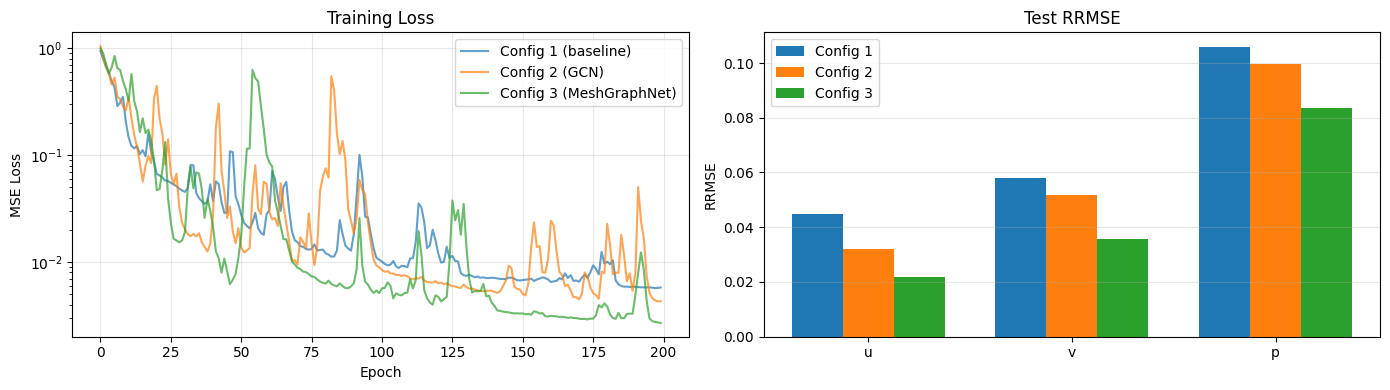

Config                           u        v        p     Params
1 (baseline)                0.0449   0.0581   0.1059      9,491
2 (GCN)                     0.0322   0.0519   0.0997     60,291
3 (MeshGraphNet)            0.0217   0.0356   0.0834    268,931


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Loss curves
axes[0].plot(losses1, label='Config 1 (baseline)', alpha=0.7)
axes[0].plot(losses2, label='Config 2 (GCN)', alpha=0.7)
axes[0].plot(losses3, label='Config 3 (MeshGraphNet)', alpha=0.7)
axes[0].set_yscale('log'); axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3); axes[0].set_title('Training Loss')

# RRMSE bar chart (final values)
labels = ['u', 'v', 'p']
r1 = rrmse1[-1][1].numpy()
r2 = rrmse2[-1][1].numpy()
r3 = rrmse3[-1][1].numpy()
x = np.arange(3)
w = 0.25
axes[1].bar(x - w, r1, w, label='Config 1')
axes[1].bar(x, r2, w, label='Config 2')
axes[1].bar(x + w, r3, w, label='Config 3')
axes[1].set_xticks(x); axes[1].set_xticklabels(labels)
axes[1].set_ylabel('RRMSE'); axes[1].legend(); axes[1].set_title('Test RRMSE')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout(); plt.show()

# Print summary table
print(f'{"Config":<25} {"u":>8} {"v":>8} {"p":>8} {"Params":>10}')
print(f'{"1 (baseline)":<25} {r1[0]:>8.4f} {r1[1]:>8.4f} {r1[2]:>8.4f} {9491:>10,}')
print(f'{"2 (GCN)":<25} {r2[0]:>8.4f} {r2[1]:>8.4f} {r2[2]:>8.4f} {60291:>10,}')
print(f'{"3 (MeshGraphNet)":<25} {r3[0]:>8.4f} {r3[1]:>8.4f} {r3[2]:>8.4f} {268931:>10,}')

Config 3 converges fastest and achieves the best test RRMSE on all fields (u=2.2%, v=3.6%, p=8.3%). Pressure is hardest to predict across all configs since it requires global information, while the no-encoder baseline (Config 1) saturates at roughly double the error due to working in 8-dim raw feature space.

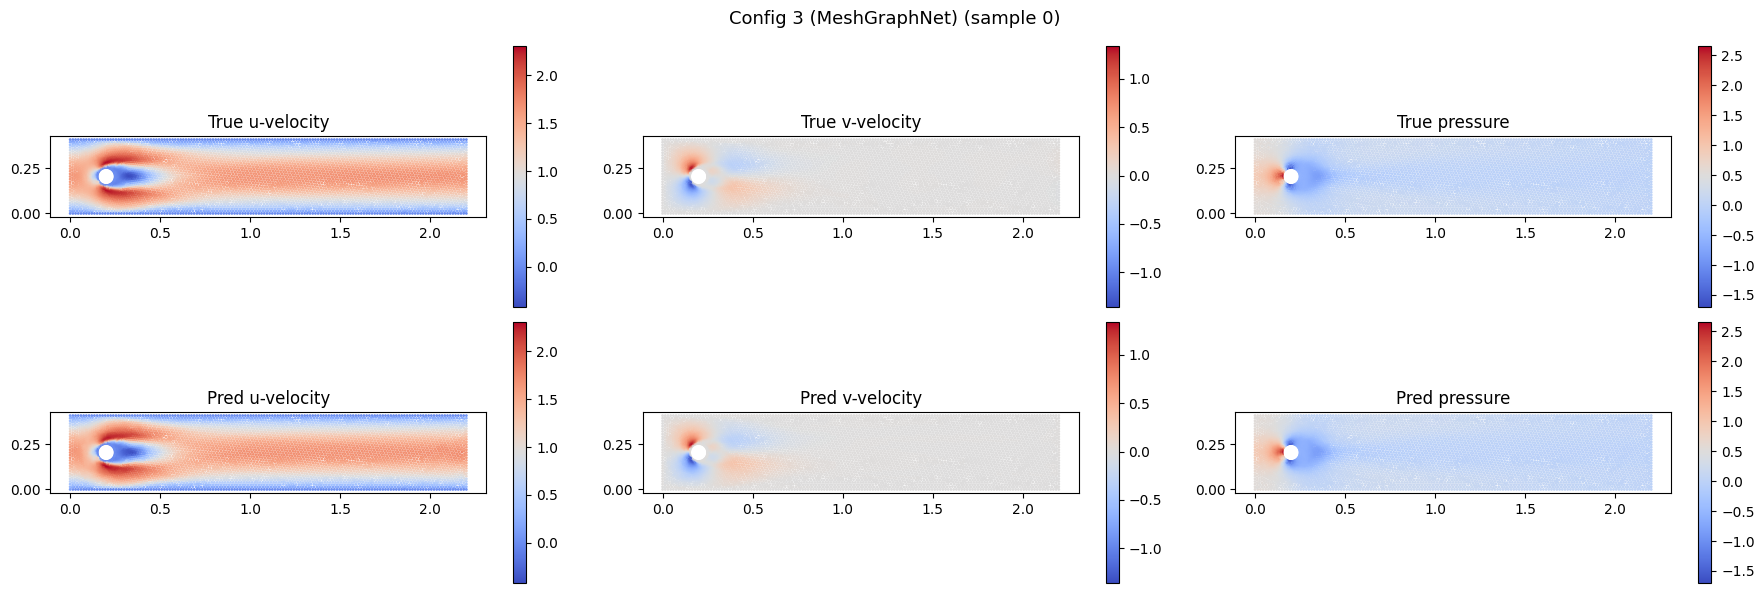

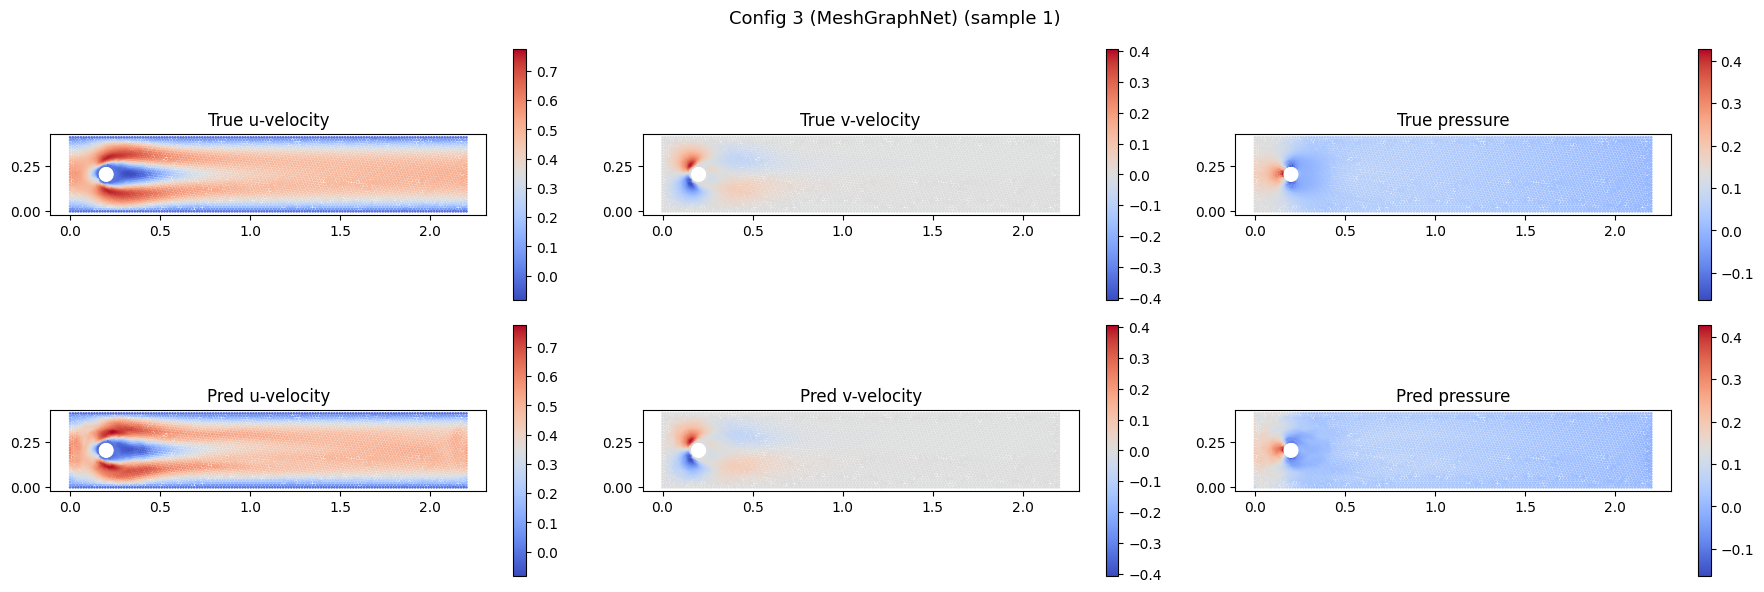

In [13]:
def plot_predictions(model, test_data, sample_idx, title_prefix=''):
    """Plot ground truth vs predicted fields for a test sample."""
    model.eval()
    data = test_data[sample_idx].to(device)
    with torch.no_grad():
        pred = model(data)
        pred_raw = (pred * y_std.to(device) + y_mean.to(device)).cpu().numpy()
    true_raw = data.y_raw.cpu().numpy()
    pos = data.pos.cpu().numpy()
    
    field_names = ['u-velocity', 'v-velocity', 'pressure']
    fig, axes = plt.subplots(2, 3, figsize=(18, 6))
    
    for j in range(3):
        vmin = min(true_raw[:, j].min(), pred_raw[:, j].min())
        vmax = max(true_raw[:, j].max(), pred_raw[:, j].max())
        sc0 = axes[0, j].scatter(pos[:, 0], pos[:, 1], c=true_raw[:, j], s=1, cmap='coolwarm', vmin=vmin, vmax=vmax)
        plt.colorbar(sc0, ax=axes[0, j])
        axes[0, j].set_title(f'True {field_names[j]}'); axes[0, j].set_aspect('equal')
        
        sc1 = axes[1, j].scatter(pos[:, 0], pos[:, 1], c=pred_raw[:, j], s=1, cmap='coolwarm', vmin=vmin, vmax=vmax)
        plt.colorbar(sc1, ax=axes[1, j])
        axes[1, j].set_title(f'Pred {field_names[j]}'); axes[1, j].set_aspect('equal')
    
    fig.suptitle(f'{title_prefix} (sample {sample_idx})', fontsize=13)
    plt.tight_layout(); plt.show()

# Plot predictions from Config 3 (best model) on two test samples
for idx in [0, 1]:
    plot_predictions(model_cfg3, test_data, idx, 'Config 3 (MeshGraphNet)')

Predicted fields closely match ground truth on both test samples, with the largest deviations barely visible near the obstacle wake where velocity gradients are steepest.

### Hyperparameter Sweep: Layers and Latent Dimensions

Testing the full MeshGraphNet (Config 3) with different depths and widths.

In [14]:
sweep_results = {}
configs = [(5, 64), (10, 64), (15, 64), (10, 32), (10, 128)]
for n_layers, latent in configs:
    key = f'L{n_layers}_D{latent}'
    print(f'\n--- {key} ---')
    model = MeshGraphNet(
        input_dim=INPUT_DIM, latent_dim=latent, output_dim=OUTPUT_DIM,
        hidden_dim=latent, edge_dim=EDGE_DIM, n_layers=n_layers,
        use_gcn=False, use_encoder=True
    ).to(device)
    n_p = sum(p.numel() for p in model.parameters())
    _, rr = train_model(model, train_data, test_data, epochs=150, lr=1e-3, log_every=150)
    final_rrmse = rr[-1][1].numpy()
    sweep_results[key] = {'rrmse': final_rrmse, 'params': n_p}
    print(f'  => u={final_rrmse[0]:.4f} v={final_rrmse[1]:.4f} p={final_rrmse[2]:.4f} | params={n_p:,}')


--- L5_D64 ---


  epoch    1 | loss=9.9989e-01 | RRMSE u=0.5261 v=0.9793 p=0.9697 | lr=1.0e-03


  epoch  150 | loss=3.7599e-03 | RRMSE u=0.0313 v=0.0462 p=0.0924 | lr=2.5e-04
  => u=0.0313 v=0.0462 p=0.0924 | params=143,171

--- L10_D64 ---


  epoch    1 | loss=9.3877e-01 | RRMSE u=0.5328 v=0.8816 p=0.9668 | lr=1.0e-03


  epoch  150 | loss=3.8318e-03 | RRMSE u=0.0299 v=0.0474 p=0.0934 | lr=5.0e-04
  => u=0.0299 v=0.0474 p=0.0934 | params=268,931

--- L15_D64 ---


...

  epoch  150 | loss=9.9996e-01 | RRMSE u=0.5831 v=1.0000 p=0.9748 | lr=1.6e-05
  => u=0.5831 v=1.0000 p=0.9748 | params=394,691

--- L10_D32 ---


  epoch    1 | loss=1.0065e+00 | RRMSE u=0.5527 v=0.9978 p=0.9756 | lr=1.0e-03


  epoch  150 | loss=4.4656e-03 | RRMSE u=0.0326 v=0.0547 p=0.0970 | lr=5.0e-04
  => u=0.0326 v=0.0547 p=0.0970 | params=68,931

--- L10_D128 ---


  epoch    1 | loss=1.0441e+00 | RRMSE u=0.5827 v=1.0000 p=0.9745 | lr=1.0e-03


  epoch  150 | loss=9.9999e-01 | RRMSE u=0.5831 v=1.0000 p=0.9748 | lr=1.6e-05
  => u=0.5831 v=1.0000 p=0.9748 | params=1,062,147



Hyperparameter sweep results (mean RRMSE across u,v,p):
Config                 u        v        p     mean     params
L5_D64            0.0313   0.0462   0.0924   0.0566    143,171
L10_D64           0.0299   0.0474   0.0934   0.0569    268,931
L15_D64           0.5831   1.0000   0.9748   0.8526    394,691
L10_D32           0.0326   0.0547   0.0970   0.0614     68,931
L10_D128          0.5831   1.0000   0.9748   0.8526  1,062,147


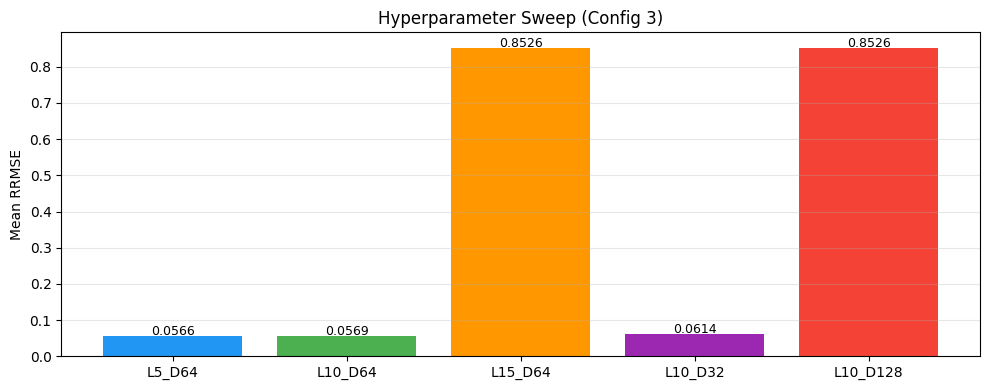

In [15]:
# Sweep results heatmap
print('\nHyperparameter sweep results (mean RRMSE across u,v,p):')
print(f'{"Config":<15} {"u":>8} {"v":>8} {"p":>8} {"mean":>8} {"params":>10}')
for key, res in sweep_results.items():
    r = res['rrmse']
    print(f'{key:<15} {r[0]:>8.4f} {r[1]:>8.4f} {r[2]:>8.4f} {r.mean():>8.4f} {res["params"]:>10,}')

# Bar chart of mean RRMSE
fig, ax = plt.subplots(figsize=(10, 4))
keys = list(sweep_results.keys())
mean_rrmse = [sweep_results[k]['rrmse'].mean() for k in keys]
colors_bar = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336']
ax.bar(keys, mean_rrmse, color=colors_bar)
ax.set_ylabel('Mean RRMSE'); ax.set_title('Hyperparameter Sweep (Config 3)')
ax.grid(True, alpha=0.3, axis='y')
for i, v in enumerate(mean_rrmse):
    ax.text(i, v + 0.002, f'{v:.4f}', ha='center', fontsize=9)
plt.tight_layout(); plt.show()

Both L15_D64 and L10_D128 completely fail to train on only 30 samples, showing that overparameterization is the main risk at this dataset scale. L5_D64 and L10_D64 perform nearly identically (~5.7% mean RRMSE), suggesting 5 message passing hops already provide sufficient receptive field for this channel geometry.

## Q4. Bonus: Edge Subsampling

Training Config 3 on edge-subsampled graphs (5%, 10%, 25% of edges kept) and evaluating on full test meshes.

In [16]:
import copy

def subsample_edges(data, ratio):
    """Keep a random fraction of edges from a PyG Data object."""
    d = data.clone()
    n_edges = d.edge_index.shape[1]
    n_keep = max(1, int(n_edges * ratio))
    perm = torch.randperm(n_edges)[:n_keep]
    d.edge_index = d.edge_index[:, perm]
    d.edge_attr = d.edge_attr[perm]
    return d

# Edge subsampling experiment
ratios = [0.05, 0.1, 0.25]
subsample_results = {}

for ratio in ratios:
    print(f'\n=== Edge ratio {ratio} ({ratio*100:.0f}% edges kept) ===')
    # Subsample training data (fresh copy each time)
    train_sub = [subsample_edges(d, ratio) for d in train_data]
    n_edges_orig = train_data[0].edge_index.shape[1]
    n_edges_sub = train_sub[0].edge_index.shape[1]
    print(f'  Edges per graph: {n_edges_orig} -> {n_edges_sub}')
    
    model_sub = MeshGraphNet(
        input_dim=INPUT_DIM, latent_dim=64, output_dim=OUTPUT_DIM,
        hidden_dim=64, edge_dim=EDGE_DIM, n_layers=10,
        use_gcn=False, use_encoder=True
    ).to(device)
    
    _, rr_sub = train_model(model_sub, train_sub, test_data, epochs=200, lr=1e-3, log_every=200)
    final_rrmse = rr_sub[-1][1].numpy()
    subsample_results[ratio] = final_rrmse
    print(f'  => u={final_rrmse[0]:.4f} v={final_rrmse[1]:.4f} p={final_rrmse[2]:.4f}')


=== Edge ratio 0.05 (5% edges kept) ===
  Edges per graph: 38702 -> 1935


  epoch    1 | loss=8.4614e-01 | RRMSE u=0.4694 v=0.9142 p=0.9685 | lr=1.0e-03


  epoch  200 | loss=3.3793e-03 | RRMSE u=0.1023 v=0.2196 p=0.2309 | lr=2.5e-04
  => u=0.1023 v=0.2196 p=0.2309

=== Edge ratio 0.1 (10% edges kept) ===
  Edges per graph: 38702 -> 3870


  epoch    1 | loss=8.7827e-01 | RRMSE u=0.5492 v=0.9490 p=0.9633 | lr=1.0e-03


  epoch  200 | loss=4.4475e-03 | RRMSE u=0.0805 v=0.1306 p=0.1853 | lr=2.5e-04
  => u=0.0805 v=0.1306 p=0.1853

=== Edge ratio 0.25 (25% edges kept) ===
  Edges per graph: 38702 -> 9675


  epoch    1 | loss=9.6736e-01 | RRMSE u=0.4795 v=0.9645 p=0.9694 | lr=1.0e-03


  epoch  200 | loss=3.4451e-03 | RRMSE u=0.0337 v=0.0685 p=0.1186 | lr=2.5e-04
  => u=0.0337 v=0.0685 p=0.1186


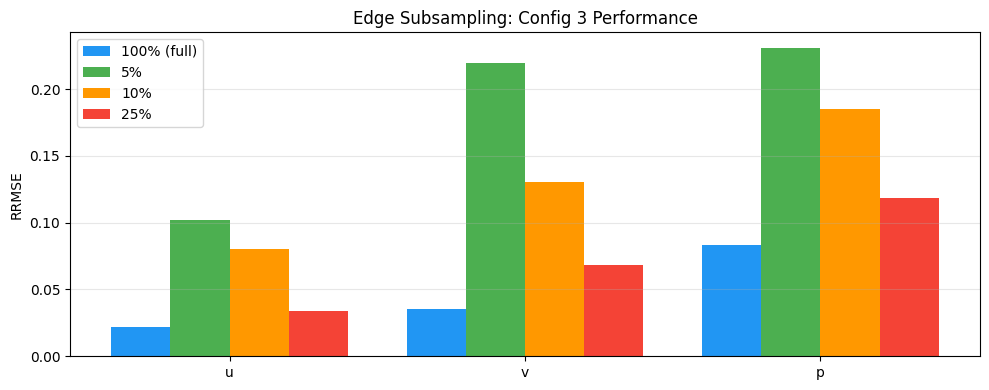

Ratio             u        v        p     mean
100% (full)   0.0217   0.0356   0.0834   0.0469
5%           0.1023   0.2196   0.2309   0.1843
10%          0.0805   0.1306   0.1853   0.1321
25%          0.0337   0.0685   0.1186   0.0736


In [17]:
# Compare subsampling results with full connectivity baseline
fig, ax = plt.subplots(figsize=(10, 4))

labels_u = ['u', 'v', 'p']
x = np.arange(3)
w = 0.2

# Full connectivity baseline from Config 3
ax.bar(x - 1.5*w, r3, w, label='100% (full)', color='#2196F3')

# Subsampled results
colors_sub = ['#4CAF50', '#FF9800', '#F44336']
for j, ratio in enumerate(ratios):
    ax.bar(x + (j - 0.5)*w, subsample_results[ratio], w, 
           label=f'{ratio*100:.0f}%', color=colors_sub[j])

ax.set_xticks(x); ax.set_xticklabels(labels_u)
ax.set_ylabel('RRMSE'); ax.set_title('Edge Subsampling: Config 3 Performance')
ax.legend(); ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout(); plt.show()

# Summary table
print(f'{"Ratio":<10} {"u":>8} {"v":>8} {"p":>8} {"mean":>8}')
print(f'{"100% (full)":<10} {r3[0]:>8.4f} {r3[1]:>8.4f} {r3[2]:>8.4f} {r3.mean():>8.4f}')
for ratio in ratios:
    r = subsample_results[ratio]
    print(f'{f"{ratio*100:.0f}%":<10} {r[0]:>8.4f} {r[1]:>8.4f} {r[2]:>8.4f} {r.mean():>8.4f}')

Keeping 25% of edges increases mean RRMSE by ~60% (7.4% vs 4.7% full), while 5% edges degrades it ~4x to 18.4%. Even heavily subsampled graphs produce reasonable predictions because 10 message passing layers still propagate information through the remaining edges.